## Extracción de Caracteristicas

Esta seccion aborda las caracteristicas a extraer para entrenar un modelo de clasificación

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, lfilter, filtfilt
from scipy.fft import rfft, rfftfreq
from scipy.stats import skew, kurtosis, entropy
import pywt
from typing import List, Tuple, Dict, Any
import os
import glob
import nolds
from joblib import Parallel, delayed
import algoritmos_deteccion as ad

c:\Users\Juan_Saa\AppData\Local\Programs\Python\Python313\Lib\site-packages\nolds\datasets.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [7]:
# ==============================================================================
# 1. Dominio del Tiempo
# ==============================================================================
def caracteristicas_tiempo(segmento: np.ndarray, rms_nominal: float) -> dict:
    """Extrae las características seleccionadas del dominio del tiempo."""
    
    rms_segmento_val = np.sqrt(np.mean(segmento**2))
    profundidad_relativa_val = rms_segmento_val / rms_nominal if rms_nominal > 1e-6 else 0.0
    pico_abs = np.max(np.abs(segmento))
    factor_cresta_val = pico_abs / rms_segmento_val if rms_segmento_val > 1e-6 else 0.0
    curtosis_val = kurtosis(segmento)
    
    return {
        'rms_segmento': rms_segmento_val,
        'profundidad_relativa': profundidad_relativa_val,
        'factor_cresta': factor_cresta_val,
        'curtosis': curtosis_val,
    }

# ==============================================================================
# 2. Dominio de la Frecuencia 
# ==============================================================================
def caracteristicas_frecuencia(segmento: np.ndarray) -> dict:
    """Extrae únicamente la energía espectral (FFT)."""
    n = len(segmento)
    if n < 2: return {'fft_energia': 0}

    fft_vals = np.fft.fft(segmento)[:n // 2]
    psd = np.abs(fft_vals)**2 / n
    energia_espectral = np.sum(psd)
    
    return {
        'fft_energia': energia_espectral,
    }

# ==============================================================================
# 3. Dominio Wavelet y Envolvente 
# ==============================================================================
def caracteristicas_wavelet(segmento: np.ndarray, wavelet: str = 'db4', max_level: int = 4) -> dict:
    """Extrae energía, entropía y desviación estándar de los coeficientes wavelet."""
    coeffs = pywt.wavedec(segmento, wavelet, level=max_level)
    caracteristicas = {}
    
    for i in range(1, len(coeffs)):
        nivel_coeffs = coeffs[-i]
        nivel = i
        
        caracteristicas[f'wavelet_energia_cD{nivel}'] = np.sum(nivel_coeffs**2)
        
        energia = caracteristicas[f'wavelet_energia_cD{nivel}']
        p = (nivel_coeffs**2) / energia if energia > 1e-6 else 0
        caracteristicas[f'wavelet_entropia_cD{nivel}'] = -np.sum(p * np.log2(p + 1e-12))
        
        caracteristicas[f'wavelet_std_cD{nivel}'] = np.std(nivel_coeffs)
        
    return caracteristicas

def caracteristicas_envolvente(senal: np.ndarray) -> dict:
    """Calcula la media y desviación estándar de la envolvente de Hilbert."""
    envolvente = np.abs(hilbert(senal))
    return {
        'env_media': np.mean(envolvente),
        'env_std': np.std(envolvente)
    }

# ==============================================================================
# 4. FUNCIÓN MAESTRA 
# ==============================================================================
def extraer_caracteristicas(segmento_evento: np.ndarray, fs: int, rms_nominal_val: float) -> dict:
    """
    Orquesta la extracción del conjunto final de características "Top 1".
    """
    caracteristicas = {}
    
    # Llama a las versiones ajustadas y a las que no necesitaron cambios
    caracteristicas.update(caracteristicas_tiempo(segmento_evento, rms_nominal_val))
    caracteristicas.update(caracteristicas_frecuencia(segmento_evento))
    caracteristicas.update(caracteristicas_wavelet(segmento_evento))
    caracteristicas.update(caracteristicas_envolvente(segmento_evento))
    
    # La lista final de características que se quiere mantener
    caracteristicas_top_1_requeridas = [
        'curtosis', 'env_media', 'env_std', 'factor_cresta', 'fft_energia', 
        'profundidad_relativa', 'rms_segmento', 'wavelet_energia_cD1', 
        'wavelet_energia_cD2', 'wavelet_energia_cD3', 'wavelet_energia_cD4', 
        'wavelet_entropia_cD1', 'wavelet_entropia_cD2', 'wavelet_entropia_cD3', 
        'wavelet_entropia_cD4', 'wavelet_std_cD1','wavelet_std_cD2','wavelet_std_cD3','wavelet_std_cD4'
    ]
    
    # Filtrar el diccionario para devolver solo las claves requeridas
    caracteristicas_filtradas = {clave: valor for clave, valor in caracteristicas.items() if clave in caracteristicas_top_1_requeridas}
    
    return caracteristicas_filtradas

In [ ]:
def procesar_un_archivo(etiqueta, ruta_archivo, fs):
    """Procesa un único archivo de señales y devuelve sus características y duraciones."""
    print(f"-> Iniciando procesamiento para: '{etiqueta}'")
    try:
        df_senales = pd.read_csv(ruta_archivo, index_col=0)
    except FileNotFoundError:
        return (None, []) # Devuelve una tupla vacía si el archivo no existe
    
    lista_features = []
    lista_duraciones = []
    for nombre_columna in df_senales.columns:
        # (Lógica de detección, consolidación y extracción idéntica a la anterior)
        senal_completa = df_senales[nombre_columna].values
        eventos_detectados = ad.detectar_eventos_con_fusion(senal_completa, fs)
        eventos_consolidados = []
        if len(eventos_detectados) > 1:
            inicio_consolidado, fin_consolidado = eventos_detectados[0][0], eventos_detectados[-1][1]
            eventos_consolidados.append((inicio_consolidado, fin_consolidado))
        elif len(eventos_detectados) == 1:
            eventos_consolidados = eventos_detectados
        
        if not eventos_consolidados: continue
        
        rms_nom_completa = ad.rms_nominal(senal_completa, fs)
        for inicio, fin in eventos_consolidados:
            segmento_evento = senal_completa[inicio:fin]
            if len(segmento_evento) == 0: continue
            
            caracteristicas = extraer_caracteristicas(segmento_evento, fs, rms_nom_completa)
            duracion = fin - inicio
            caracteristicas['etiqueta'] = etiqueta
            caracteristicas['columna_origen'] = nombre_columna
            caracteristicas['duracion_muestras'] = duracion
            lista_features.append(caracteristicas)
            lista_duraciones.append(duracion)

    if not lista_features: return (None, [])
    
    print(f"-> Finalizado: '{etiqueta}'")
    return (pd.DataFrame(lista_features), lista_duraciones)

def generar_features_normales(ruta_archivo_normal, duraciones_reales, fs, num_muestras):
    """Genera las características para la clase Normal."""
    print("\n--- Procesando la clase 'Normal' ---")
    try:
        df_normales = pd.read_csv(ruta_archivo_normal, index_col=0)
    except FileNotFoundError:
        print(f"  -> ERROR: No se encontró el archivo de señales normales.")
        return None
        
    senales_normales_pool = [df_normales[col].values for col in df_normales.columns]
    lista_features_normales = []

    for _ in range(num_muestras):
        duracion_aleatoria = np.random.choice(duraciones_reales)
        idx_senal = np.random.randint(0, len(senales_normales_pool))
        senal_completa = senales_normales_pool[idx_senal]

        if len(senal_completa) > duracion_aleatoria:
            inicio = np.random.randint(0, len(senal_completa) - duracion_aleatoria)
            segmento = senal_completa[inicio : inicio + duracion_aleatoria]
            rms_nom = ad.rms_nominal(senal_completa, fs)
            caracteristicas = extraer_caracteristicas(segmento, fs, rms_nom)
            caracteristicas['etiqueta'] = 'Normal'
            caracteristicas['columna_origen'] = f'normal_from_pool_{idx_senal}'
            caracteristicas['duracion_muestras'] = duracion_aleatoria
            lista_features_normales.append(caracteristicas)

    if not lista_features_normales: return None
    
    return pd.DataFrame(lista_features_normales)


# ==============================================================================
# SECCIÓN DE CONFIGURACIÓN Y ORQUESTACIÓN
# ==============================================================================
if __name__ == '__main__':
    
    FS = 7200
    NUM_MUESTRAS_NORMALES = 4100
    DIRECTORIO_SALIDA = 'Dataset_Final_Generado'
    DIRECTORIO_TEMP = os.path.join(DIRECTORIO_SALIDA, 'temp')
    NOMBRE_ARCHIVO_CONSOLIDADO = 'Dataset_Caracteristicas_Final.csv'

    ARCHIVOS_A_PROCESAR = {
        'Sag': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag\Clase_1_sag.csv',
        'Sag_Armonico': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Armonic\Clase_2_Armonico.csv',
        'Sag_Multiple': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Multiple\Clase_3_sagmultiple.csv',
        'Sag_Notch': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Notch\Clase_4_sagnotch.csv',
        'Sag_Transitorios': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Transitorios\Clase_5_Transitorios.csv'
    }
    RUTA_ARCHIVO_NORMAL = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Normal\Clase_0_normal.csv'

    # --- LÓGICA PRINCIPAL OPTIMIZADA ---
    os.makedirs(DIRECTORIO_TEMP, exist_ok=True)
    
    # --- LÓGICA PRINCIPAL PARALELIZADA ---
    print("--- FASE 1: Procesando archivos de eventos en paralelo ---")
    
    # n_jobs=-1 usa todos los núcleos disponibles de tu CPU
    resultados_paralelos = Parallel(n_jobs=-1)(
        delayed(procesar_un_archivo)(etiqueta, ruta, FS) for etiqueta, ruta in ARCHIVOS_A_PROCESAR.items()
    )

    # Desempaquetar los resultados
    lista_dfs_eventos = [res[0] for res in resultados_paralelos if res[0] is not None]
    todas_las_duraciones = [duracion for res in resultados_paralelos for duracion in res[1]]
    
    print(f"\nSe procesaron {len(lista_dfs_eventos)} clases de eventos.")

    # FASE 2: Procesar clase normal (esto es rápido, no necesita paralelismo)
    if todas_las_duraciones:
        df_normal = generar_features_normales(RUTA_ARCHIVO_NORMAL, todas_las_duraciones, FS, NUM_MUESTRAS_NORMALES)
        if df_normal is not None:
            lista_dfs_eventos.append(df_normal)

    # FASE 3: Consolidar todos los resultados
    print("\n--- FASE 3: Consolidando todos los resultados ---")
    if not lista_dfs_eventos:
        print("No se generaron características para consolidar.")
    else:
        df_final = pd.concat(lista_dfs_eventos, ignore_index=True).fillna(0)
        
        columnas_info = ['etiqueta', 'columna_origen', 'duracion_muestras']
        columnas_features = sorted([col for col in df_final.columns if col not in columnas_info])
        df_final = df_final[columnas_info + columnas_features]

        os.makedirs(DIRECTORIO_SALIDA, exist_ok=True)
        ruta_salida_completa = os.path.join(DIRECTORIO_SALIDA, NOMBRE_ARCHIVO_CONSOLIDADO)
        df_final.to_csv(ruta_salida_completa, index=False)
        
        print(f"\n¡ÉXITO! Se guardó el dataset final en '{ruta_salida_completa}'")
        print("Conteo de eventos por clase en el dataset final:")
        print(df_final['etiqueta'].value_counts())

## PCA Analisis de  Componentes Principales

Dimensiones originales de X: (24600, 19)


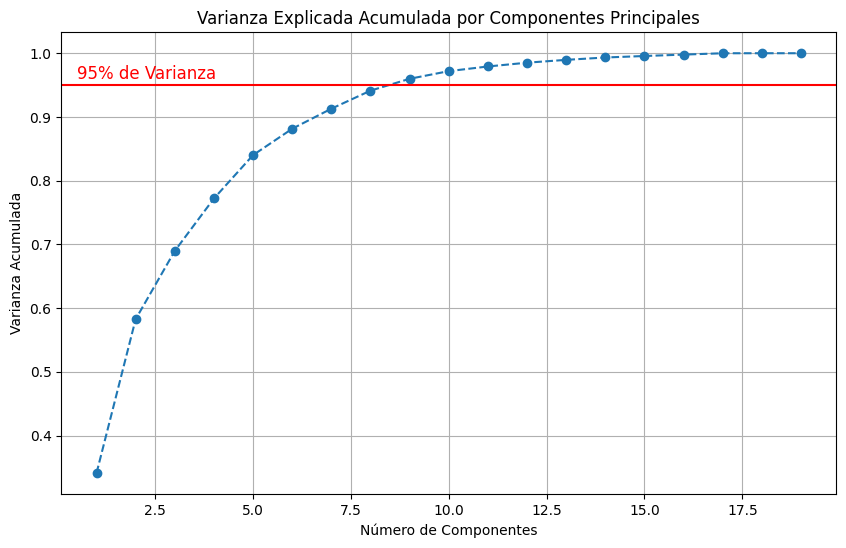

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Carga tu dataset (si no lo tienes ya cargado)
csv = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Final_Generado\Dataset_Caracteristicas_Final.csv'
df_final = pd.read_csv(csv)

# Separa las características (X) y la etiqueta (y)
X = df_final.drop(columns=['etiqueta', 'columna_origen','duracion_muestras']) # Quitamos las columnas no numéricas/identificadoras
y = df_final['etiqueta']

print("Dimensiones originales de X:", X.shape)

# Crea el objeto escalador
scaler = StandardScaler()

# Ajusta y transforma los datos
X_scaled = scaler.fit_transform(X)

# 1. Aplicar PCA para conservar TODOS los componentes inicialmente
pca = PCA()
X_pca_temp = pca.fit_transform(X_scaled)

# 2. Calcular la varianza explicada acumulada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 3. Graficar la varianza explicada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.96, '95% de Varianza', color = 'red', fontsize=12)
plt.show()

In [38]:
# Elige el número de componentes (ej. 10)
N_COMPONENTS = 10

# Aplica PCA con el número de componentes seleccionado
pca_final = PCA(n_components=N_COMPONENTS)
X_pca_final = pca_final.fit_transform(X_scaled)

print("Dimensiones de X después de PCA:", X_pca_final.shape)

Dimensiones de X después de PCA: (24600, 10)


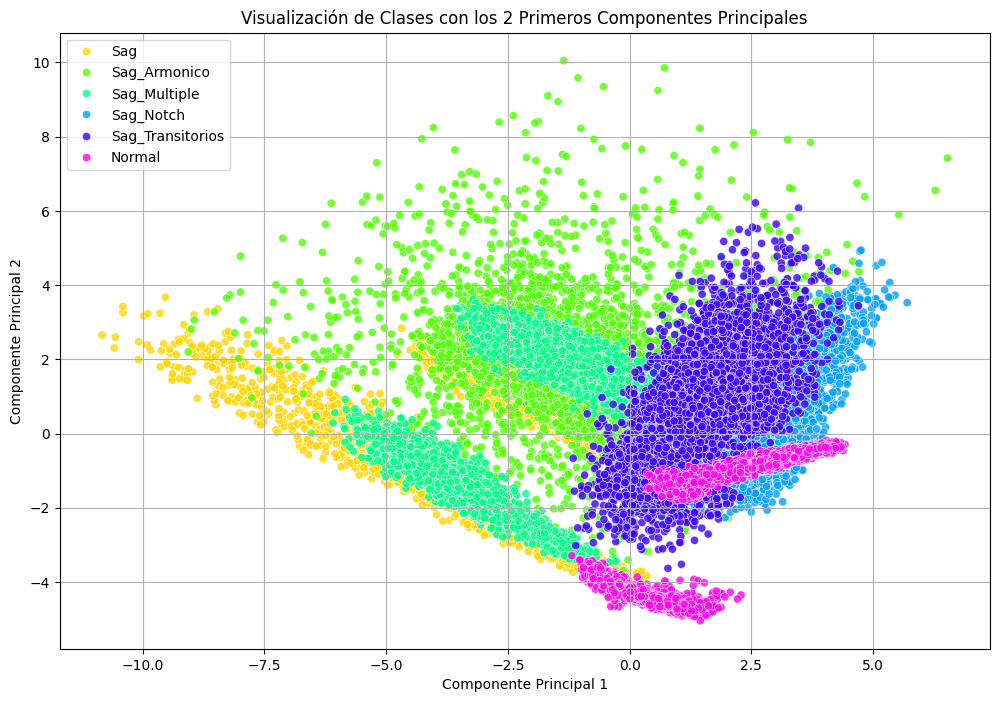

In [ ]:
# Crea un DataFrame con los dos primeros componentes y las etiquetas
df_pca_viz = pd.DataFrame(
    data=X_pca_final[:, 0:2], 
    columns=['Componente Principal 1', 'Componente Principal 2']
)
df_pca_viz['etiqueta'] = y


# Grafica con Seaborn
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Componente Principal 1', 
    y='Componente Principal 2',
    hue='etiqueta',
    palette=sns.color_palette("hsv", len(y.unique())), # Colores distintos para cada clase
    data=df_pca_viz,
    alpha=0.8
)
plt.title('Visualización de Clases con los 2 Primeros Componentes Principales')
plt.legend(loc='best')
plt.grid()
plt.show()

## LDA análisis discriminante lineal

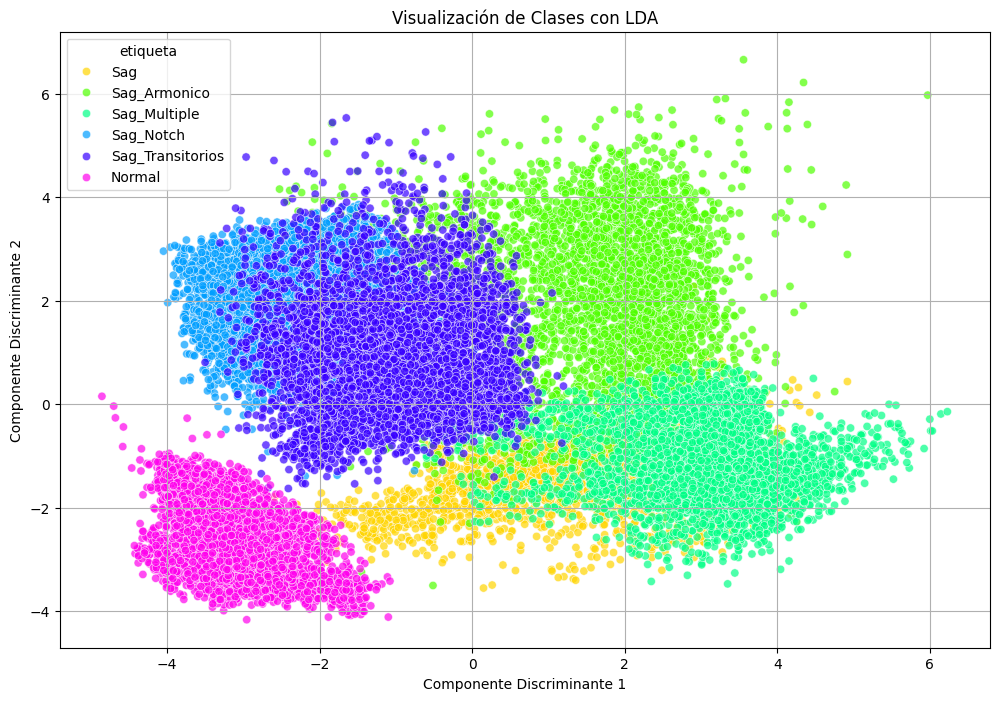

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
# --- Carga y Preparación de Datos 
data = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Final_Generado\Dataset_Caracteristicas_Final.csv'
df = pd.read_csv(data) 
X = df.drop(columns=['etiqueta', 'columna_origen','duracion_muestras'])
y = df['etiqueta']

le = LabelEncoder()                                                    
y_encoded = le.fit_transform(y)

# Asumimos que tienes tus datos originales (antes de PCA)
# X_scaled: tus características originales escaladas
# y_encoded: tus etiquetas codificadas numéricamente

# 1. Crear e instanciar el objeto LDA
# Nota: n_components no puede ser mayor que (n_clases - 1)
lda = LDA(n_components=2) # Lo ponemos en 2 para poder visualizarlo

# 2. Ajustar y transformar los datos
# ¡NOTA LA DIFERENCIA! Fit necesita tanto X como y.
X_lda = lda.fit_transform(X_scaled, y_encoded)

# 3. Visualizar los resultados
df_lda_viz = pd.DataFrame(
    data=X_lda,
    columns=['Componente Discriminante 1', 'Componente Discriminante 2']
)
df_lda_viz['etiqueta'] = le.inverse_transform(y_encoded) # Usar el LabelEncoder para obtener los nombres originales

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Componente Discriminante 1',
    y='Componente Discriminante 2',
    hue='etiqueta',
    palette=sns.color_palette("hsv", len(y.unique())),
    data=df_lda_viz,
    alpha=0.7
)
plt.title('Visualización de Clases con LDA')
plt.grid()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Importar los clasificadores
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# --- 1. Carga y Preparación de Datos ---
data = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Final_Generado\Dataset_Caracteristicas_Final.csv'
df = pd.read_csv(data)
X = df.drop(columns=['etiqueta', 'columna_origen', 'duracion_muestras'])
y = df['etiqueta']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# --- 2. Escalado de Características ---
# Es mejor escalar los datos una sola vez aquí, antes de PCA o LDA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. FASE CLAVE: Reducción de Dimensionalidad ---
# Elige UNA de las dos opciones (descomenta la que quieras usar)

# --- OPCIÓN A: Usar PCA ---
print("Aplicando PCA para reducir a 19 componentes...")
pca = PCA(n_components=19)
X_reducido = pca.fit_transform(X_scaled)
print(f"Dimensiones después de PCA: {X_reducido.shape}")

# # --- OPCIÓN B: Usar LDA ---
# print("Aplicando LDA para reducir a 5 componentes...")
# lda = LDA(n_components=5) # Máximo n_clases - 1
# X_reducido = lda.fit_transform(X_scaled, y_encoded)
# print(f"Dimensiones después de LDA: {X_reducido.shape}")


# --- 4. Comparativa de Clasificadores ---
# 1. Definir los modelos
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "k-NN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# 2. Bucle de evaluación
results = {}
print("\n--- Iniciando Comparativa de Clasificadores con Datos Reducidos ---")
for name, model in models.items():
    # El pipeline ahora es más simple, solo contiene el clasificador
    pipeline = Pipeline([
        ('classifier', model)
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # ¡Aquí usamos los datos transformados!
    scores = cross_val_score(pipeline, X_reducido, y_encoded, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f"{name}: Precisión Media = {scores.mean():.4f} (Desv. Est. = {scores.std():.4f})")

print("\n--- Comparativa Finalizada ---")

Aplicando LDA para reducir a 5 componentes...
Dimensiones después de LDA: (24600, 5)

--- Iniciando Comparativa de Clasificadores con Datos Reducidos ---
Logistic Regression: Precisión Media = 0.9184 (Desv. Est. = 0.0021)
SVM: Precisión Media = 0.9365 (Desv. Est. = 0.0013)
k-NN: Precisión Media = 0.9367 (Desv. Est. = 0.0031)
Random Forest: Precisión Media = 0.9380 (Desv. Est. = 0.0016)


c:\Users\Juan_Saa\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:09:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Juan_Saa\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:09:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Juan_Saa\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:09:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Juan_Saa\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:09:18] WARNI

XGBoost: Precisión Media = 0.9378 (Desv. Est. = 0.0024)

--- Comparativa Finalizada ---
